<a href="https://colab.research.google.com/github/Piratesk1/Kubat/blob/main/moje_mapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.8 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import heapq

Délka: 1534 m,  uzlů: 22


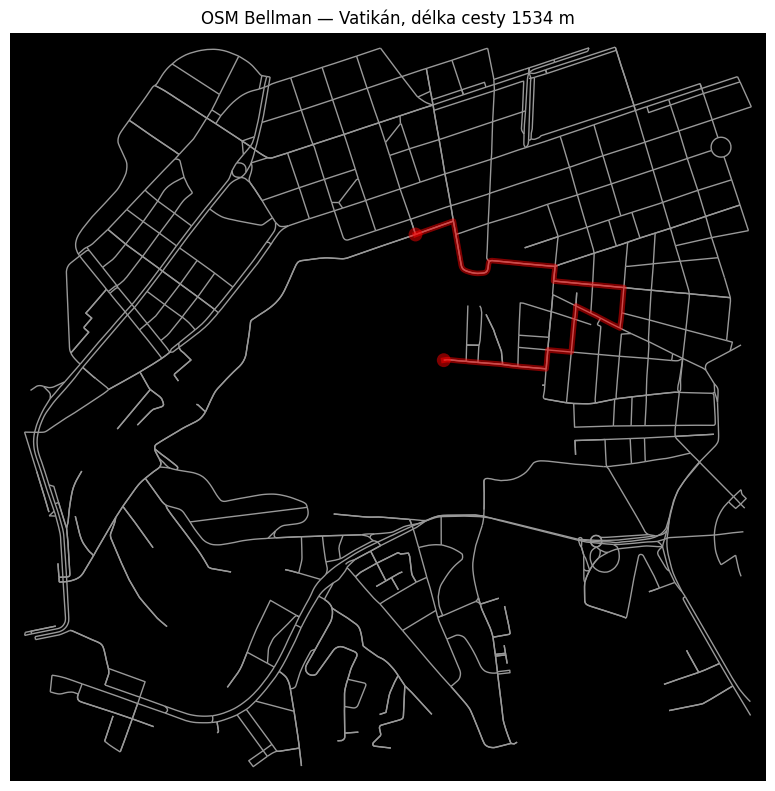

In [6]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# ── STARTOVNÍ A CÍLOVÝ BOD (Vatikán) ────────────────────────────────
start_gps = (41.9029, 12.4534)  # Náměstí sv. Petra
cil_gps   = (41.9065, 12.4536)  # Vatikánská muzea

# Using graph_from_point instead of graph_from_place to resolve geocoding issue
G = ox.graph_from_point(start_gps, dist=1000, network_type="drive", simplify=True)

def bellman_ford(graf, start, cil):
    uzly = list(graf.nodes)
    hrany = [(u, v, d["length"]) for u, v, d in graf.edges(data=True)]

    dist = {u: float("inf") for u in uzly}
    dist[start] = 0
    odkud = {u: None for u in uzly}

    for _ in range(len(uzly) - 1):
        zmenilo_se = False
        for u, v, vaha in hrany:
            if dist[u] + vaha < dist[v]:
                dist[v] = dist[u] + vaha
                odkud[v] = u
                zmenilo_se = True
        if not zmenilo_se:
            break

    cesta, uzel = [], cil
    while uzel is not None:
        cesta.append(uzel)
        uzel = odkud[uzel]
    cesta.reverse()

    return dist[cil], cesta

start = ox.nearest_nodes(G, X=start_gps[1], Y=start_gps[0])
cil   = ox.nearest_nodes(G, X=cil_gps[1],   Y=cil_gps[0])

delka, cesta = bellman_ford(G, start, cil)
print(f"Délka: {delka:.0f} m,  uzlů: {len(cesta)}")

# ── VIZUALIZACE ───────────────────────────────────────────────────────
fig, ax = ox.plot_graph_route(
    G, cesta,
    route_color="red", route_linewidth=4,
    node_size=0, bgcolor="black", node_color="white",
    show=False, close=False,
)
ax.set_title(f"OSM Bellman — Vatikán, délka cesty {delka:.0f} m")
plt.tight_layout()
plt.savefig("bellman_ford_vatikan.png", dpi=150, bbox_inches="tight")
plt.show()